In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv("Cardetails.csv")

In [5]:
df.shape

(8128, 13)

In [7]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [9]:
df.isnull().sum()


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

# Target Variable Analysis (selling_price)

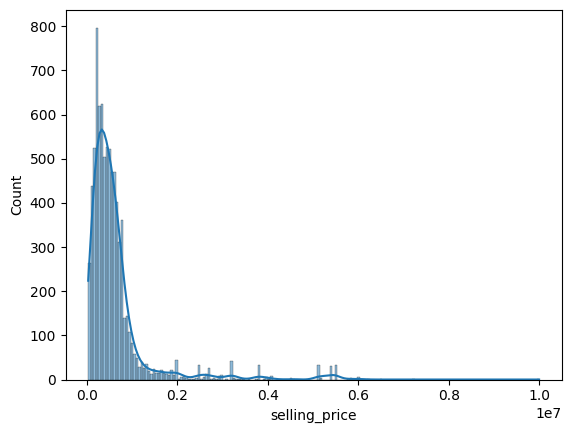

In [10]:
sns.histplot(df['selling_price'], kde=True)
plt.show()


Outliers

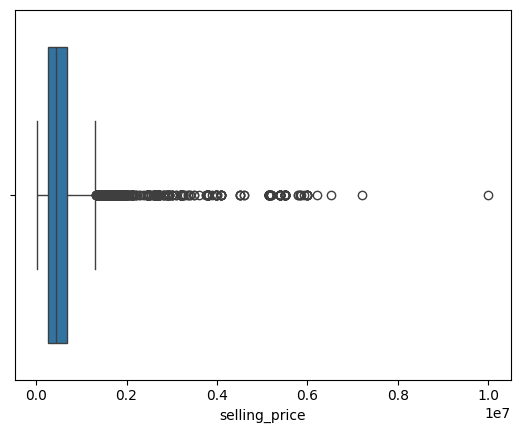

In [16]:
sns.boxplot(x=df['selling_price'])

plt.show()


# Year vs Selling Price

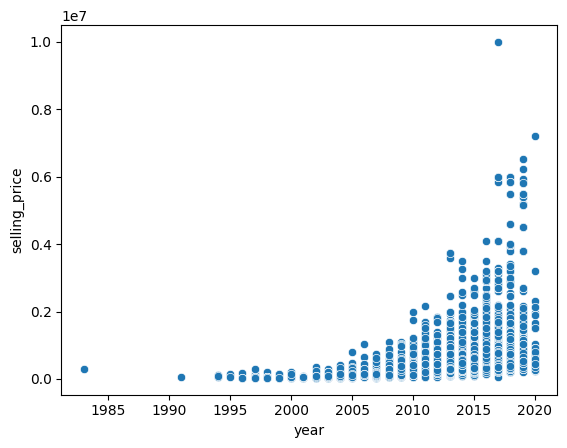

In [17]:
sns.scatterplot(x='year', y='selling_price', data=df)
plt.show()


# KM Driven vs Price

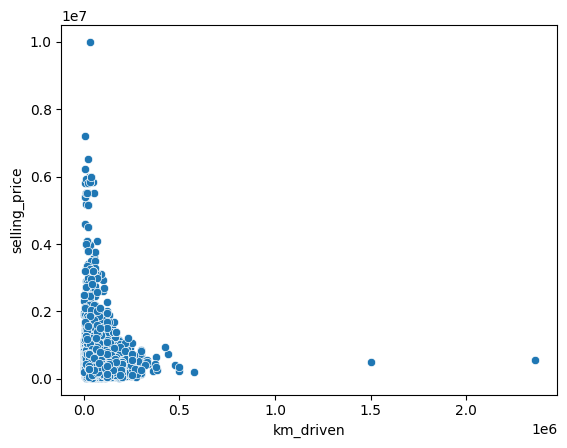

In [18]:
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.show()


# Categorical Feature Analysis

Fuel Type

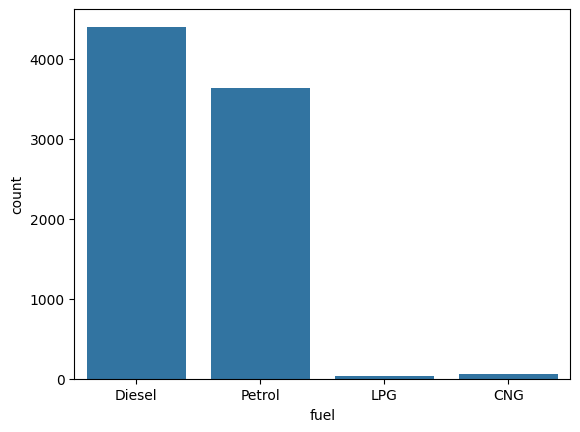

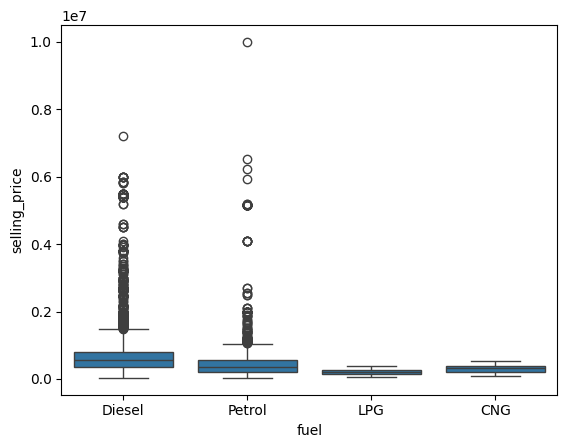

In [19]:
sns.countplot(x='fuel', data=df)
plt.show()

sns.boxplot(x='fuel', y='selling_price', data=df)
plt.show()


Transmission

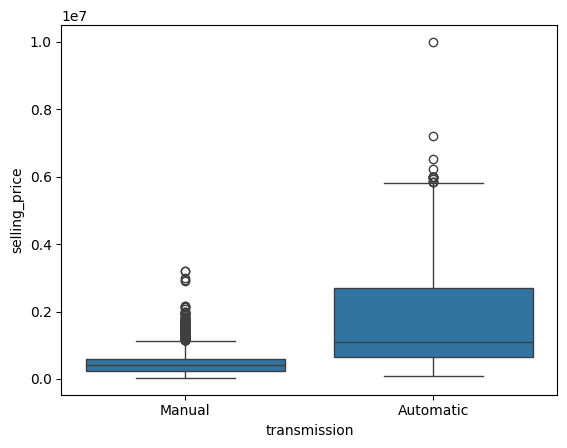

In [20]:
sns.boxplot(x='transmission', y='selling_price', data=df)
plt.show()


Seller Type

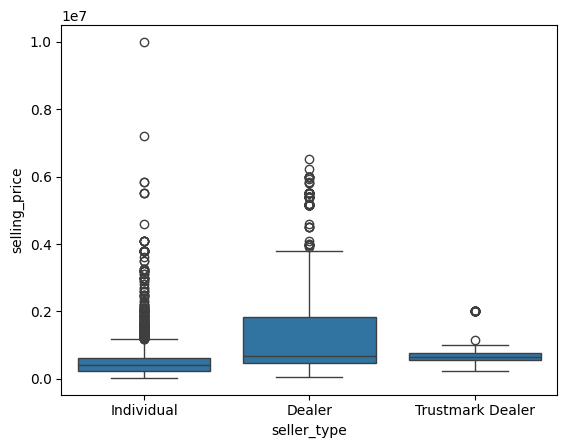

In [21]:
sns.boxplot(x='seller_type', y='selling_price', data=df)
plt.show()


Owenership

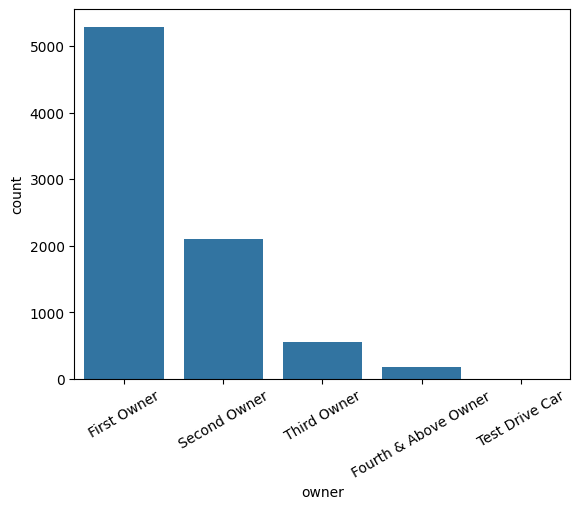

In [22]:
sns.countplot(x='owner', data=df)
plt.xticks(rotation=30)
plt.show()


# Seats Available

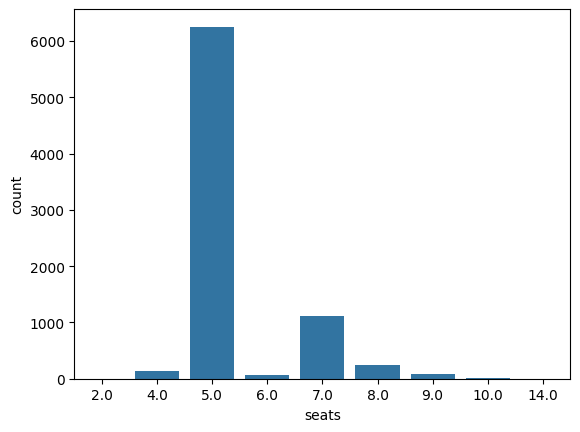

In [23]:
sns.countplot(x='seats', data=df)
plt.show()


# Cleaning Insight 

In [24]:
df[['mileage','engine','max_power','torque']].head()


,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"


# Brand Analysis (From Name)

In [26]:
df['brand'] = df['name'].str.split().str[0]
df['brand'].value_counts().head(10)


brand
Maruti        2448
Hyundai       1415
Mahindra       772
Tata           734
Toyota         488
Honda          467
Ford           397
Chevrolet      230
Renault        228
Volkswagen     186
Name: count, dtype: int64

Maruti Hyundai dominate the dataset

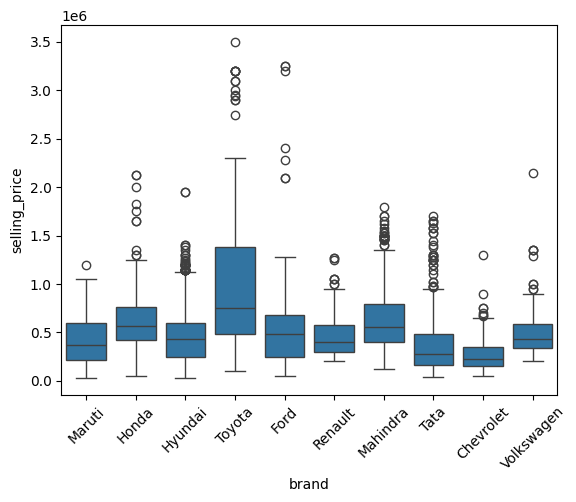

In [27]:
top_brands = df['brand'].value_counts().head(10).index
sns.boxplot(x='brand', y='selling_price',
            data=df[df['brand'].isin(top_brands)])
plt.xticks(rotation=45)
plt.show()


# Correlation Analysis

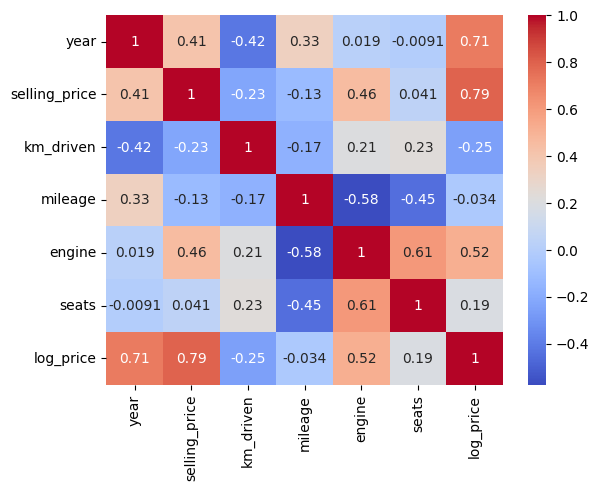

In [29]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


# FINAL EDA SUMMARY

- Dataset contains 8,128 used car records with 13 features
- Selling price is right-skewed with significant outliers
- Newer cars and lower km-driven cars command higher prices
- Automatic transmission and diesel fuel cars are more expensive
- First-owner vehicles have higher resale value
- Brand, engine capacity, and power strongly affect selling price
- Mileage, engine, max_power require data cleaning before modeling
